# LangGraph Workshop

## Configuration

### Configure environment

In [2]:
import logging
import os

from dotenv import find_dotenv, load_dotenv

In [3]:
load_dotenv(find_dotenv('.env'))

True

In [4]:
os.environ["LANGCHAIN_PROJECT"] = "LangGraph Workshop"

#### Optional configuration

**LangSmith**

In [5]:
load_dotenv(find_dotenv('.env.langsmith'))

False

### Configure LM Studio (Local OpenAI-compatible)

In [6]:
from langchain_openai import ChatOpenAI
from langchain_ollama import OllamaEmbeddings, OllamaLLM

In [7]:
# # LM Studio local server configuration
# LM_STUDIO_BASE_URL = "http://localhost:8090/v1"  # Default LM Studio API endpoint
# model_name = "GigaChat-2-Pro"  # or your specific Qwen model name in LM Studio

# llm = ChatOpenAI(
#     model=model_name,
#     base_url=LM_STUDIO_BASE_URL,
#     api_key="lm-studio",  # LM Studio doesn't require a real API key
#     temperature=0,
# )

# llm.invoke("Hello")

# LM Studio local server configuration
# Default LM Studio API endpoint
inference_server_url = "http://localhost:11434/v1" 

# Initialize ChatOpenAI, pointing to your local server
llm = ChatOpenAI(
    model="qwen2",  # The name of the model you pulled/are serving locally
    openai_api_key="no-key",  # A dummy key, as it's not needed for local servers
    openai_api_base=inference_server_url,
    temperature=0.7,  # Adjust as needed
)


llm.invoke(input="Hello")

AIMessage(content="Hello! How can I help you today? Let me know if you have any questions or need information on specific topics. Whether it's about science, technology, history, current events, or anything else, feel free to ask. I'm here to provide assistance and share knowledge.", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 20, 'total_tokens': 77, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-756', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--cf7bddce-b98c-4ecc-a576-cfa2ae940206-0', usage_metadata={'input_tokens': 20, 'output_tokens': 57, 'total_tokens': 77, 'input_token_details': {}, 'output_token_details': {}})

In [8]:
SYSTEM_PROMPT = ""

## Part 1: Build a Basic Chatbot

In [9]:
from typing import Annotated

from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

### Create `StateGraph`

In [10]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

### Add a `chatbot` node

In [11]:
def chatbot(state: State):
    return {"messages": [llm.invoke([("system", SYSTEM_PROMPT)] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

### Add an `entry` point

In [12]:
graph_builder.add_edge(START, "chatbot")

### Set a `finish` point

In [13]:
graph_builder.add_edge("chatbot", END)

### Compile the graph

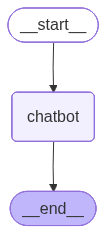

In [14]:
graph = graph_builder.compile()
graph

### Visualize the graph

In [15]:
from IPython.display import Image, display

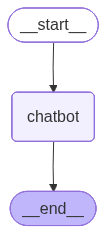

In [16]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [17]:
from langchain_core.messages import HumanMessage
from pydantic_core import PydanticSerializationError

In [18]:
def stream_graph_updates(graph, user_input, config=None):
    if user_input:
        data = {"messages": ("user", user_input)}
    else:
        data = None
        
    for event in graph.stream(
        data, 
        stream_mode="updates",
        config=config
    ):
        node, data = list(event.items())[0]
        
        if "messages" in data and len(data['messages']) > 0:
            print(data["messages"][-1])

In [19]:
# Привет! Меня зовут Вася.
# Как меня зовут?
# Кто выиграл Евро 2024 по футболу?

while True:
    user_input = input("User:")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        break
    
    stream_graph_updates(graph, user_input)

EmptyInputError: Received no input for __start__

## Part 2: 🛠️ Enhancing the Chatbot with Tools

In [20]:
from langchain_community.tools.tavily_search import TavilySearchResults

### Create `StateGraph`

In [21]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

### Define the tool

In [22]:
load_dotenv(find_dotenv('.env'))

True

In [23]:
from langchain_community.tools.tavily_search.tool import TavilyInput
from pydantic import BaseModel, Field

In [24]:
class TavilyInput(BaseModel):
    """Входные данные для поискового запроса."""

    query: str = Field(description="Текст поискового запроса")

In [25]:
tool = TavilySearchResults(
    max_results=5,
    args_schema=TavilyInput,
)
tools = [tool]
# tool.invoke("Что такое LangGraph?")

/tmp/ipykernel_45723/2965207883.py:1: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(


### Bind tools to LLM

In [26]:
llm_with_tools = llm.bind_tools(tools)

### Add a `chatbot` node

In [27]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

### Add a `tools` node

In [28]:
import json

from langchain_core.messages import ToolMessage

In [29]:
class BasicToolNode:
    """A node that runs the tools requested in the last AIMessage."""

    def __init__(self, tools: list) -> None:
        self.tools_by_name = {tool.name: tool for tool in tools}

    def __call__(self, inputs: dict):
        if messages := inputs.get("messages", []):
            message = messages[-1]
        else:
            raise ValueError("No message found in input")
            
        outputs = []
        
        for tool_call in message.tool_calls:
            tool_result = self.tools_by_name[tool_call["name"]].invoke(
                tool_call["args"]
            )
            outputs.append(
                ToolMessage(
                    content=json.dumps(tool_result, ensure_ascii=False),
                    name=tool_call["name"],
                    tool_call_id=tool_call["id"],
                )
            )
            
        return {"messages": outputs}


tool_node = BasicToolNode(tools=[tool])
graph_builder.add_node("tools", tool_node)

### Add conditional edge

In [30]:
def route_tools(
    state: State,
):
    """
    Use in the conditional_edge to route to the ToolNode if the last message
    has tool calls. Otherwise, route to the end.
    """
    if isinstance(state, list):
        ai_message = state[-1]
    elif messages := state.get("messages", []):
        ai_message = messages[-1]
    else:
        raise ValueError(f"No messages found in input state to tool_edge: {state}")
    if hasattr(ai_message, "tool_calls") and len(ai_message.tool_calls) > 0:
        return "tools"
    return END

In [31]:
graph_builder.add_conditional_edges(
    "chatbot",
    route_tools,
    {"tools": "tools", END: END},
)

### Add another edges

In [32]:
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("tools", "chatbot")

### Compile the graph

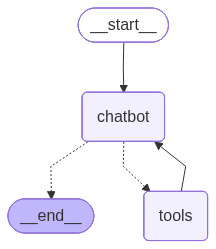

In [33]:
graph = graph_builder.compile()
graph

### Visualize the graph

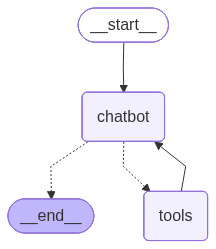

In [34]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [36]:
# Привет! Меня зовут Вася.
# Как меня зовут?
# Кто выиграл Евро 2024 по футболу?

while True:
    user_input = input("User:")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        break
    
    stream_graph_updates(graph, user_input)

content="It seems like you're not calling any specific function provided in the tools. If you need to use one of these functions, please provide a query or specify which function you want to use along with your request. For example:\n\n" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 79, 'prompt_tokens': 173, 'total_tokens': 252, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-479', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--46f62aac-5c0f-434b-a396-12873061cf19-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'How is the weather today?'}, 'id': 'call_g4vy2dqa', 'type': 'tool_call'}] usage_metadata={'input_tokens': 173, 'output_tokens': 79, 'total_tokens': 252, 'input_token_details': {}, 'output_token_details': {}}
content='[{"title": "Weather for New York, New York, USA - Time and D

KeyboardInterrupt: 

## Part 3: Adding Memory to the Chatbot

### Create `MemorySaver` checkpointer

In [37]:
from langgraph.checkpoint.memory import MemorySaver

In [38]:
memory = MemorySaver()

### Create `StateGraph`

In [39]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

### Define the tool

In [41]:
class TavilyInput(BaseModel):
    """Входные данные для поискового запроса."""

    query: str = Field(description="Текст поискового запроса")

In [42]:
tool = TavilySearchResults(
    max_results=5,
    args_schema=TavilyInput
)
tools = [tool]
# tool.invoke("Что такое LangGraph?")

### Bind tools to LLM

In [43]:
llm_with_tools = llm.bind_tools(tools)

### Add a `chatbot` node

In [44]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

### Add a `tools` node

In [45]:
from langgraph.prebuilt import ToolNode, tools_condition

In [46]:
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

### Add conditional edge

In [47]:
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

### Add another edges

In [48]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

### Compile the graph

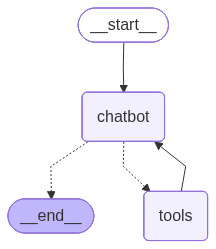

In [49]:
graph = graph_builder.compile(checkpointer=memory)
graph

### Visualize the graph

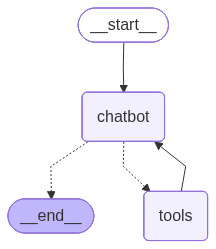

In [50]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [51]:
import inspect
from uuid import uuid4

In [52]:
# Привет! Меня зовут Вася.
# Как меня зовут?
# Кто выиграл Евро 2024 по футболу?

config = {"configurable": {"thread_id": str(uuid4())}}

while True:
    user_input = input("User:")
    
    if user_input.lower() in ["quit", "exit", "q"]:
        break
    
    stream_graph_updates(graph, user_input, config=config)

content="To clarify, it seems like you've mentioned a name, John. If there's an action or information you require using the provided function, please provide more details. For example:\n\n" additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 101, 'prompt_tokens': 173, 'total_tokens': 274, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-937', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--d5e77398-5e07-48d4-b75d-90c4cb3ea8c5-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'John Doe biography'}, 'id': 'call_xvow151n', 'type': 'tool_call'}] usage_metadata={'input_tokens': 173, 'output_tokens': 101, 'total_tokens': 274, 'input_token_details': {}, 'output_token_details': {}}
content='[{"title": "John Doe (musician) Facts for Kids - Kiddle encyclopedia", "url": "https://kids.kiddle.co/John_Doe_(m

KeyboardInterrupt: 

In [54]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Привет! Меня зовут Вася."

stream_graph_updates(graph, user_input, config=config)

content='Привет, Вася! Как я могу помочь вам сегодня?' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 183, 'total_tokens': 200, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-746', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--10269962-f890-4c0d-ba37-a14d1ac7a92e-0' usage_metadata={'input_tokens': 183, 'output_tokens': 17, 'total_tokens': 200, 'input_token_details': {}, 'output_token_details': {}}


In [55]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Привет! Меня зовут Вася.', additional_kwargs={}, response_metadata={}, id='dca0526b-5c96-43f1-b88e-0fcb331a39d4'), AIMessage(content='Привет, Вася! Как я могу помочь вам сегодня?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 183, 'total_tokens': 200, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-746', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--10269962-f890-4c0d-ba37-a14d1ac7a92e-0', usage_metadata={'input_tokens': 183, 'output_tokens': 17, 'total_tokens': 200, 'input_token_details': {}, 'output_token_details': {}})]}, next=(), config={'configurable': {'thread_id': 'bc8b4eb8-9f52-4e6a-aed2-a714e9c97b9d', 'checkpoint_ns': '', 'checkpoint_id': '1f0c567e-5da5-6e58-8001-8775f361ca9d'}}, metadata={'source': 'loop', 'step': 1, 'paren

In [56]:
print(inspect.getsource(snapshot.__class__))

class StateSnapshot(NamedTuple):
    """Snapshot of the state of the graph at the beginning of a step."""

    values: dict[str, Any] | Any
    """Current values of channels."""
    next: tuple[str, ...]
    """The name of the node to execute in each task for this step."""
    config: RunnableConfig
    """Config used to fetch this snapshot."""
    metadata: CheckpointMetadata | None
    """Metadata associated with this snapshot."""
    created_at: str | None
    """Timestamp of snapshot creation."""
    parent_config: RunnableConfig | None
    """Config used to fetch the parent snapshot, if any."""
    tasks: tuple[PregelTask, ...]
    """Tasks to execute in this step. If already attempted, may contain an error."""
    interrupts: tuple[Interrupt, ...]
    """Interrupts that occurred in this step that are pending resolution."""



In [57]:
for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Привет! Меня зовут Вася.
================================== Ai Message ==================================

Привет, Вася! Как я могу помочь вам сегодня?


In [58]:
state_history = list(graph.get_state_history(config))
print(len(state_history))

3


In [59]:
user_input = "Как меня зовут?"

stream_graph_updates(graph, user_input, config=config)

content='Вас зовут Вася.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 215, 'total_tokens': 224, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-981', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--5f7832be-5ce3-4fd6-803c-6d064b8ba26a-0' usage_metadata={'input_tokens': 215, 'output_tokens': 9, 'total_tokens': 224, 'input_token_details': {}, 'output_token_details': {}}


In [60]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Привет! Меня зовут Вася.', additional_kwargs={}, response_metadata={}, id='dca0526b-5c96-43f1-b88e-0fcb331a39d4'), AIMessage(content='Привет, Вася! Как я могу помочь вам сегодня?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 183, 'total_tokens': 200, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-746', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--10269962-f890-4c0d-ba37-a14d1ac7a92e-0', usage_metadata={'input_tokens': 183, 'output_tokens': 17, 'total_tokens': 200, 'input_token_details': {}, 'output_token_details': {}}), HumanMessage(content='Как меня зовут?', additional_kwargs={}, response_metadata={}, id='2b844e14-aaaa-4da6-bc30-7de48c7e8434'), AIMessage(content='Вас зовут Вася.', additional_kwargs={'refusal': None}, response_met

In [61]:
for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Привет! Меня зовут Вася.
================================== Ai Message ==================================

Привет, Вася! Как я могу помочь вам сегодня?
================================ Human Message =================================

Как меня зовут?
================================== Ai Message ==================================

Вас зовут Вася.


In [62]:
state_history = list(graph.get_state_history(config))
print(len(state_history))

6


In [63]:
state_history

[StateSnapshot(values={'messages': [HumanMessage(content='Привет! Меня зовут Вася.', additional_kwargs={}, response_metadata={}, id='dca0526b-5c96-43f1-b88e-0fcb331a39d4'), AIMessage(content='Привет, Вася! Как я могу помочь вам сегодня?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 183, 'total_tokens': 200, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-746', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--10269962-f890-4c0d-ba37-a14d1ac7a92e-0', usage_metadata={'input_tokens': 183, 'output_tokens': 17, 'total_tokens': 200, 'input_token_details': {}, 'output_token_details': {}}), HumanMessage(content='Как меня зовут?', additional_kwargs={}, response_metadata={}, id='2b844e14-aaaa-4da6-bc30-7de48c7e8434'), AIMessage(content='Вас зовут Вася.', additional_kwargs={'refusal': None}, response_me

In [64]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Как меня зовут?"

stream_graph_updates(graph, user_input, config=config)

content='Ваш запрос не включает определенной информации о том, как вас зовут. Пожалуйста, скажите свой именем.' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 176, 'total_tokens': 211, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-884', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--6f75d804-0966-4123-aeca-05fd09b49ee1-0' usage_metadata={'input_tokens': 176, 'output_tokens': 35, 'total_tokens': 211, 'input_token_details': {}, 'output_token_details': {}}


In [67]:
snapshot = graph.get_state(config)
snapshot

StateSnapshot(values={'messages': [HumanMessage(content='Как меня зовут?', additional_kwargs={}, response_metadata={}, id='9c7b6930-e798-4ea0-8176-b77d4db0fe06'), AIMessage(content='Ваш запрос не включает определенной информации о том, как вас зовут. Пожалуйста, скажите свой именем.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 176, 'total_tokens': 211, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-884', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--6f75d804-0966-4123-aeca-05fd09b49ee1-0', usage_metadata={'input_tokens': 176, 'output_tokens': 35, 'total_tokens': 211, 'input_token_details': {}, 'output_token_details': {}})]}, next=(), config={'configurable': {'thread_id': '3a17a814-7597-4829-99ec-745c2441918d', 'checkpoint_ns': '', 'checkpoint_id': '1f0c5681-0900-61e4-8001-b3a2d72d5179'}

In [66]:
state_history = list(graph.get_state_history(config))
print(len(state_history))

3


## Part 4: Human-in-the-loop

### Create `StateGraph`

In [68]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

### Define the tool

In [69]:
class TavilyInput(BaseModel):
    """Входные данные для поискового запроса."""

    query: str = Field(description="Текст поискового запроса")

In [70]:
tool = TavilySearchResults(
    max_results=5,
    args_schema=TavilyInput
)
tools = [tool]
# tool.invoke("Что такое LangGraph?")

### Bind tools to LLM

In [71]:
llm_with_tools = llm.bind_tools(tools)

### Add a `chatbot` node

In [72]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

### Add a `tools` node

In [73]:
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

### Add conditional edge

In [74]:
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

### Add another edges

In [75]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

### Create `MemorySaver` checkpointer

In [76]:
memory = MemorySaver()

### Compile the graph

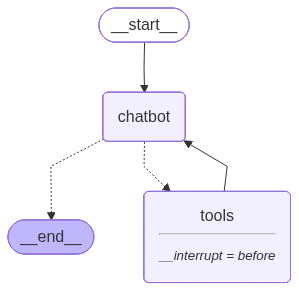

In [77]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"]
)
graph

### Visualize the graph

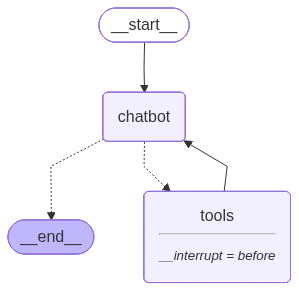

In [78]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [79]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Я изучаю LangGraph. Можешь мне собрать информацию по нему?"

stream_graph_updates(graph, user_input, config=config)

content='' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 189, 'total_tokens': 220, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'qwen2', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-642', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--35b8f5bc-b55a-4e95-86bf-aa26f4f511ff-0' tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'LangGraph study'}, 'id': 'call_siqfxrt7', 'type': 'tool_call'}] usage_metadata={'input_tokens': 189, 'output_tokens': 31, 'total_tokens': 220, 'input_token_details': {}, 'output_token_details': {}}


In [80]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

In [81]:
existing_message = snapshot.values["messages"][-1]
existing_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'LangGraph study'},
  'id': 'call_siqfxrt7',
  'type': 'tool_call'}]

In [82]:
stream_graph_updates(graph, None, config=config)

content='[{"title": "LangGraph: A Framework for Building Stateful Multi-Agent LLM ...", "url": "https://medium.com/@ken_lin/langgraph-a-framework-for-building-stateful-multi-agent-llm-applications-a51d5eb68d03", "content": "Creating a functional LangGraph application begins with installation through pip: pip install langgraph. The implementation process involves defining nodes, establishing connections between them, and specifying the execution flow. Nodes in LangGraph can represent various components such as LLM agents, tool executors, or data processors, each responsible for specific functionality within the overall system. [...] LangGraph provides a clear and intuitive mechanism for defining coordination between multiple agents or components in a system. The graph-based structure visually represents how information flows between components, making it easier to design, implement, and reason about complex multi-agent workflows. This explicit coordination model helps prevent common iss

KeyboardInterrupt: 

## Part 5: Manually Updating the State

### Create `StateGraph`

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

### Define the tool

In [ ]:
class TavilyInput(BaseModel):
    """Входные данные для поискового запроса."""

    query: str = Field(description="Текст поискового запроса")

In [ ]:
tool = TavilySearchResults(
    max_results=5,
    args_schema=TavilyInput
)
tools = [tool]
# tool.invoke("Что такое LangGraph?")

### Bind tools to LLM

### Add a `chatbot` node

In [ ]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

### Add a `tools` node

In [ ]:
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

### Add conditional edge

In [ ]:
graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

### Add another edges

In [ ]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

### Create `MemorySaver` checkpointer

In [ ]:
memory = MemorySaver()

### Compile the graph

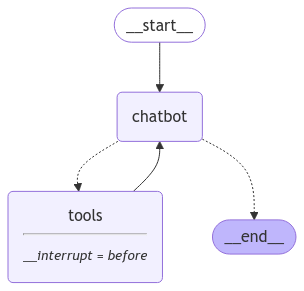

In [ ]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["tools"]
)
graph

### Visualize the graph

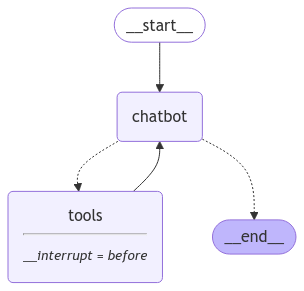

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [ ]:
from langchain_core.messages import AIMessage, ToolMessage

#### Manually update state

In [ ]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Я изучаю LangGraph. Можешь мне собрать информацию по нему?"

stream_graph_updates(graph, user_input, config=config)

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (762aa617-29ca-476f-a8b9-1ac7a2fceea1)
 Call ID: 762aa617-29ca-476f-a8b9-1ac7a2fceea1
  Args:
    query: LangGraph


In [ ]:
snapshot = graph.get_state(config)
snapshot.next

('tools',)

In [ ]:
existing_message = snapshot.values["messages"][-1]
existing_message.tool_calls

[{'name': 'tavily_search_results_json',
  'args': {'query': 'LangGraph'},
  'id': '762aa617-29ca-476f-a8b9-1ac7a2fceea1',
  'type': 'tool_call'}]

In [ ]:
answer = (
    "LangGraph это библиотека для создания агентов с использованием LLM"
)
new_messages = [
    ToolMessage(content=answer, tool_call_id=existing_message.tool_calls[0]["id"]),
    AIMessage(content=answer),
]

new_messages[-1].pretty_print()

graph.update_state(
    config,
    {"messages": new_messages},
)

print("\n\nLast 2 messages;")
print(graph.get_state(config).values["messages"][-2:])

================================== Ai Message ==================================

LangGraph это библиотека для создания агентов с использованием LLM


Last 2 messages;
[ToolMessage(content='LangGraph это библиотека для создания агентов с использованием LLM', id='d8d129a2-2eff-4043-8bb6-5ad74a3c18b6', tool_call_id='762aa617-29ca-476f-a8b9-1ac7a2fceea1'), AIMessage(content='LangGraph это библиотека для создания агентов с использованием LLM', additional_kwargs={}, response_metadata={}, id='158b9565-b0e1-466f-ad8d-9f20ca9cfd45')]


In [ ]:
graph.update_state(
    config,
    {"messages": [AIMessage(content="Я эксперт в AI!")]},
    as_node="chatbot",
)

{'configurable': {'thread_id': '1f9e1a72-5988-46a4-87d1-55b33a111350',
  'checkpoint_ns': '',
  'checkpoint_id': '1efbd413-d7bd-6326-8003-ee7c0e31a907'}}

In [ ]:
print("Last 3 messages;")
snapshot = graph.get_state(config)

print(snapshot.values["messages"][-3:])
print(snapshot.next)

Last 3 messages;
[ToolMessage(content='LangGraph это библиотека для создания агентов с использованием LLM', id='d8d129a2-2eff-4043-8bb6-5ad74a3c18b6', tool_call_id='762aa617-29ca-476f-a8b9-1ac7a2fceea1'), AIMessage(content='LangGraph это библиотека для создания агентов с использованием LLM', additional_kwargs={}, response_metadata={}, id='158b9565-b0e1-466f-ad8d-9f20ca9cfd45'), AIMessage(content='Я эксперт в AI!', additional_kwargs={}, response_metadata={}, id='8fc7cb54-4c78-4f7c-a015-bca19cd536fa')]
()


In [ ]:
snapshot = graph.get_state(config)

for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Я изучаю LangGraph. Можешь мне собрать информацию по нему?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (762aa617-29ca-476f-a8b9-1ac7a2fceea1)
 Call ID: 762aa617-29ca-476f-a8b9-1ac7a2fceea1
  Args:
    query: LangGraph
================================= Tool Message =================================

LangGraph это библиотека для создания агентов с использованием LLM
================================== Ai Message ==================================

LangGraph это библиотека для создания агентов с использованием LLM
================================== Ai Message ==================================

Я эксперт в AI!


In [ ]:
user_input = "Какой был ответ на мой последний вопрос?"

stream_graph_updates(graph, user_input, config)

================================== Ai Message ==================================

Ваш последний вопрос касался информации о LangGraph, и я ответил, что LangGraph - это библиотека для создания агентов с использованием LLM (Large Language Model).


#### Overwrite existing messages

In [ ]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Я изучаю LangGraph. Можешь мне собрать информацию по нему?"

stream_graph_updates(graph, user_input, config=config)

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (67fb1cee-d253-4b46-b03d-8a1d293be197)
 Call ID: 67fb1cee-d253-4b46-b03d-8a1d293be197
  Args:
    query: LangGraph


In [ ]:
snapshot = graph.get_state(config)
existing_message = snapshot.values["messages"][-1]

print("Original")
print("Message ID", existing_message.id)
print(existing_message.tool_calls[0])
new_tool_call = existing_message.tool_calls[0].copy()
new_tool_call["args"]["query"] = "LangGraph human-in-the-loop workflow"
new_message = AIMessage(
    content=existing_message.content,
    tool_calls=[new_tool_call],
    id=existing_message.id,
)

print("\n\nUpdated")
print(new_message.tool_calls[0])
print("Message ID", new_message.id)
graph.update_state(config, {"messages": [new_message]})

print("\n\nTool calls")
print(graph.get_state(config).values["messages"][-1].tool_calls)

Original
Message ID run-dc8aff3c-f88c-49ea-8687-54c4b3ad2321-0
{'name': 'tavily_search_results_json', 'args': {'query': 'LangGraph'}, 'id': '67fb1cee-d253-4b46-b03d-8a1d293be197', 'type': 'tool_call'}


Updated
{'name': 'tavily_search_results_json', 'args': {'query': 'LangGraph human-in-the-loop workflow'}, 'id': '67fb1cee-d253-4b46-b03d-8a1d293be197', 'type': 'tool_call'}
Message ID run-dc8aff3c-f88c-49ea-8687-54c4b3ad2321-0


Tool calls
[{'name': 'tavily_search_results_json', 'args': {'query': 'LangGraph human-in-the-loop workflow'}, 'id': '67fb1cee-d253-4b46-b03d-8a1d293be197', 'type': 'tool_call'}]


In [ ]:
graph.get_state(config).values["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (67fb1cee-d253-4b46-b03d-8a1d293be197)
 Call ID: 67fb1cee-d253-4b46-b03d-8a1d293be197
  Args:
    query: LangGraph human-in-the-loop workflow


In [ ]:
stream_graph_updates(graph, None, config=config)

================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.youtube.com/watch?v=9BPCV5TYPmg", "content": "In this video, I'll show you how to handle persistence with LangGraph, enabling a unique Human-in-the-Loop workflow. This approach allows a human to grant an"}, {"url": "https://blog.langchain.dev/making-it-easier-to-build-human-in-the-loop-agents-with-interrupt/", "content": "Making it easier to build human-in-the-loop agents with interrupt Making it easier to build human-in-the-loop agents with interrupt Today, we’re excited to announce a new method to more easily include human-in-the-loop steps in your LangGraph agents: interrupt How we built LangGraph for human-in-the-loop workflows interrupt: a new developer experience for human-in-the-loop We’ve had a few ways of building human in the loop interactions before (breakpoints, NodeInterrupt). When building human-in-the-loop into Python programs, one comm

In [ ]:
snapshot = graph.get_state(config)

for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Я изучаю LangGraph. Можешь мне собрать информацию по нему?
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (67fb1cee-d253-4b46-b03d-8a1d293be197)
 Call ID: 67fb1cee-d253-4b46-b03d-8a1d293be197
  Args:
    query: LangGraph human-in-the-loop workflow
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.youtube.com/watch?v=9BPCV5TYPmg", "content": "In this video, I'll show you how to handle persistence with LangGraph, enabling a unique Human-in-the-Loop workflow. This approach allows a human to grant an"}, {"url": "https://blog.langchain.dev/making-it-easier-to-build-human-in-the-loop-agents-with-interrupt/", "content": "Making it easier to build human-in-the-loop agents with interrupt Making it easier to build human-in-the-loop agents with interrupt To

In [ ]:
user_input = "О чем я спрашивал в последний раз?"

stream_graph_updates(graph, user_input, config=config)

================================== Ai Message ==================================

В прошлый раз вы интересовались информацией о LangGraph и его использовании в рабочих процессах с участием человека (human-in-the-loop).


## Part 6: Customizing State

### Create `StateGraph`

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    ask_human: bool

graph_builder = StateGraph(State)

### Define the tools

In [ ]:
class RequestAssistance(BaseModel):
    """Escalate the conversation to an expert. Use this if you are unable to assist directly or if the user requires support beyond your permissions.

    To use this function, relay the user's 'request' so the expert can provide the right guidance.
    """

    request: str

In [ ]:
class TavilyInput(BaseModel):
    """Входные данные для поискового запроса."""

    query: str = Field(description="Текст поискового запроса")

In [ ]:
tool = TavilySearchResults(
    max_results=5,
    args_schema=TavilyInput
)
tools = [tool] 
# tool.invoke("Что такое LangGraph?")

### Bind tools to LLM

In [ ]:
llm_with_tools = llm.bind_tools(tools + [RequestAssistance])

### Add a `chatbot` node

In [ ]:
def chatbot(state: State):
    response = llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + state["messages"])
    
    ask_human = False
    if (
        response.tool_calls
        and response.tool_calls[0]["name"] == RequestAssistance.__name__
    ):
        ask_human = True
        
    return {"messages": [response], "ask_human": ask_human}
    
graph_builder.add_node("chatbot", chatbot)

### Add a `tools` node

In [ ]:
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

### Add a `human` node

In [ ]:
def create_response(response: str, ai_message: AIMessage):
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]["id"],
    )


def human_node(state: State):
    new_messages = []
    
    if not isinstance(state["messages"][-1], ToolMessage):
        new_messages.append(
            create_response("No response from human.", state["messages"][-1])
        )
        
    return {
        "messages": new_messages,
        "ask_human": False,
    }


graph_builder.add_node("human", human_node)

### Add conditional edge

In [ ]:
def select_next_node(state: State):
    if state["ask_human"]:
        return "human"

    return tools_condition(state)


graph_builder.add_conditional_edges(
    "chatbot",
    select_next_node,
    {"human": "human", "tools": "tools", END: END},
)

### Add another edges

In [ ]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("human", "chatbot")
graph_builder.add_edge(START, "chatbot")

### Create `MemorySaver` checkpointer

In [ ]:
memory = MemorySaver()

### Compile the graph

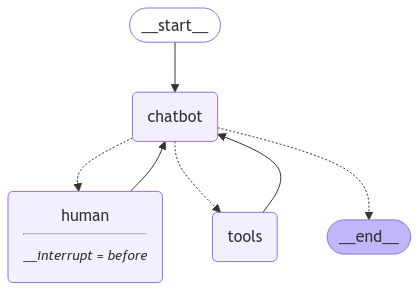

In [ ]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["human"]
)
graph

### Visualize the graph

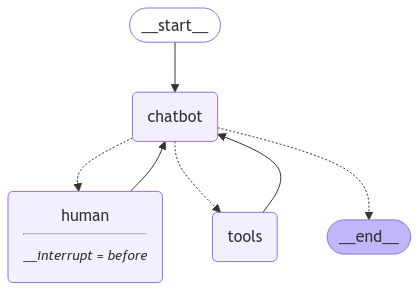

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [ ]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Мне нужен совет по созданию агентов. Можешь ли ты запросить помощь в этом?"

stream_graph_updates(graph, user_input, config)

================================== Ai Message ==================================
Tool Calls:
  RequestAssistance (6ba05562-9cfc-4f86-8928-9e77aff0b02c)
 Call ID: 6ba05562-9cfc-4f86-8928-9e77aff0b02c
  Args:
    request: Мне нужен совет по созданию агентов. Можешь ли ты запросить помощь в этом?


In [ ]:
snapshot = graph.get_state(config)
snapshot.next

('human',)

In [ ]:
ai_message = snapshot.values["messages"][-1]

human_response = (
    "Рекомендуем вам обратить внимание на LangGraph для создания вашего агента."
    " Это гораздо более надежный и расширяемый инструмент, чем простые автономные агенты."
)
tool_message = create_response(human_response, ai_message)

graph.update_state(config, {"messages": [tool_message]})

{'configurable': {'thread_id': '06a4112d-ad2f-43b1-ae75-24598215a898',
  'checkpoint_ns': '',
  'checkpoint_id': '1efbd46d-aae5-6be0-8002-486688881bde'}}

In [ ]:
graph.get_state(config).next

('human',)

In [ ]:
snapshot = graph.get_state(config)

for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Мне нужен совет по созданию агентов. Можешь ли ты запросить помощь в этом?
================================== Ai Message ==================================
Tool Calls:
  RequestAssistance (6ba05562-9cfc-4f86-8928-9e77aff0b02c)
 Call ID: 6ba05562-9cfc-4f86-8928-9e77aff0b02c
  Args:
    request: Мне нужен совет по созданию агентов. Можешь ли ты запросить помощь в этом?
================================= Tool Message =================================

Рекомендуем вам обратить внимание на LangGraph для создания вашего агента. Это гораздо более надежный и расширяемый инструмент, чем простые автономные агенты.


In [ ]:
stream_graph_updates(graph, None, config)

================================== Ai Message ==================================

Эксперт рекомендует использовать LangGraph для создания вашего агента. Это более надежный и расширяемый инструмент по сравнению с простыми автономными агентами.


## Part 7: Time Travel

### Create `StateGraph`

In [ ]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    ask_human: bool

graph_builder = StateGraph(State)

### Define the tools

In [ ]:
class RequestAssistance(BaseModel):
    """Escalate the conversation to an expert. Use this if you are unable to assist directly or if the user requires support beyond your permissions.

    To use this function, relay the user's 'request' so the expert can provide the right guidance.
    """

    request: str

In [ ]:
class TavilyInput(BaseModel):
    """Входные данные для поискового запроса."""

    query: str = Field(description="Текст поискового запроса")

In [ ]:
tool = TavilySearchResults(
    max_results=5,
    args_schema=TavilyInput
)
tools = [tool] 
# tool.invoke("Что такое LangGraph?")

### Bind tools to LLM

In [ ]:
llm_with_tools = llm.bind_tools(tools + [RequestAssistance])

### Add a `chatbot` node

In [ ]:
def chatbot(state: State):
    response = llm_with_tools.invoke([("system", SYSTEM_PROMPT)] + state["messages"])
    ask_human = False
    
    if (
        response.tool_calls
        and response.tool_calls[0]["name"] == RequestAssistance.__name__
    ):
        ask_human = True
        
    return {"messages": [response], "ask_human": ask_human}
    
graph_builder.add_node("chatbot", chatbot)

### Add a `tools` node

In [ ]:
tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

### Add a `human` node

In [ ]:
def create_response(response: str, ai_message: AIMessage):
    return ToolMessage(
        content=response,
        tool_call_id=ai_message.tool_calls[0]["id"],
    )


def human_node(state: State):
    new_messages = []
    
    if not isinstance(state["messages"][-1], ToolMessage):
        new_messages.append(
            create_response("No response from human.", state["messages"][-1])
        )
        
    return {
        "messages": new_messages,
        "ask_human": False,
    }


graph_builder.add_node("human", human_node)

### Add conditional edge

In [ ]:
def select_next_node(state: State):
    if state["ask_human"]:
        return "human"

    return tools_condition(state)


graph_builder.add_conditional_edges(
    "chatbot",
    select_next_node,
    {"human": "human", "tools": "tools", END: END},
)

### Add another edges

In [ ]:
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge("human", "chatbot")
graph_builder.add_edge(START, "chatbot")

### Create `MemorySaver` checkpointer

In [ ]:
memory = MemorySaver()

### Compile the graph

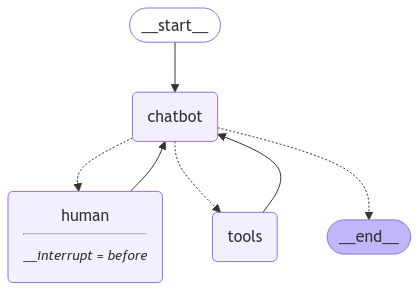

In [ ]:
graph = graph_builder.compile(
    checkpointer=memory,
    interrupt_before=["human"]
)
graph

### Visualize the graph

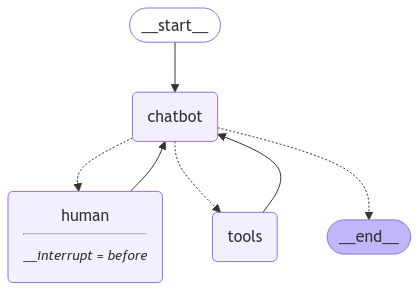

In [ ]:
display(Image(graph.get_graph().draw_mermaid_png()))

### Run chatbot

In [ ]:
config = {"configurable": {"thread_id": str(uuid4())}}

user_input = "Найди информацию про основные возможности LangGraph"

stream_graph_updates(graph, user_input, config=config)

================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (efd8beb9-179b-46d4-ac24-ee8562ad3ae9)
 Call ID: efd8beb9-179b-46d4-ac24-ee8562ad3ae9
  Args:
    query: основные возможности LangGraph
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.datacamp.com/tutorial/langgraph-tutorial", "content": "LangGraph can be used to build a wide range of applications. Chatbots. LangGraph is ideal for developing sophisticated chatbots that can handle a wide array of user requests. By leveraging multiple LLM agents, these chatbots can process natural language queries, provide accurate responses, and seamlessly switch between different conversation"}, {"url": "https://blog.futuresmart.ai/langgraph-tutorial-for-beginners", "content": "By representing workflows as cyclical graphs, LangGraph allows developers to orchestrate the interactions of multiple L

In [ ]:
user_input = "Да, это полезно. Может быть, я построю автономного агента с его помощью!"

stream_graph_updates(graph, user_input, config=config)

================================== Ai Message ==================================

Отличная идея! Построение автономного агента с использованием LangGraph действительно открывает множество возможностей. Вот несколько шагов, которые помогут вам начать этот процесс:

### Шаг 1: Определите цели вашего агента

Прежде чем приступить к разработке, определитесь с тем, какую задачу будет решать ваш агент. Например, он может помогать пользователям находить информацию, отвечать на вопросы или выполнять определенные действия в приложении.

### Шаг 2: Выберите подходящие модели ИИ

LangGraph позволяет использовать различные модели ИИ (LLM), такие как GPT-3 от OpenAI, BERT от Google и другие. Подберите те, которые лучше всего подходят для вашей задачи.

### Шаг 3: Создайте графовую структуру

Определите узлы графа, которые будут представлять разные этапы работы вашего агента. Узлы могут включать обработку текста, анализ данных, генерацию ответов и т.д. Затем соедините эти узлы ребрами, чтобы определ

In [ ]:
to_replay = None

for state in graph.get_state_history(config):
    print("Num Messages: ", len(state.values["messages"]), "Next: ", state.next)
    print("-" * 80)
    
    if len(state.values["messages"]) == 2:
        to_replay = state

Num Messages:  6 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  5 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ('__start__',)
--------------------------------------------------------------------------------
Num Messages:  4 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  3 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  2 Next:  ('tools',)
--------------------------------------------------------------------------------
Num Messages:  1 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  0 Next:  ('__start__',)
--------------------------------------------------------------------------------


In [ ]:
snapshot = graph.get_state(config)

for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Найди информацию про основные возможности LangGraph
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (efd8beb9-179b-46d4-ac24-ee8562ad3ae9)
 Call ID: efd8beb9-179b-46d4-ac24-ee8562ad3ae9
  Args:
    query: основные возможности LangGraph
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://www.datacamp.com/tutorial/langgraph-tutorial", "content": "LangGraph can be used to build a wide range of applications. Chatbots. LangGraph is ideal for developing sophisticated chatbots that can handle a wide array of user requests. By leveraging multiple LLM agents, these chatbots can process natural language queries, provide accurate responses, and seamlessly switch between different conversation"}, {"url": "https://blog.futuresmart.ai/langgraph-tutorial-for-beginners

In [ ]:
print(to_replay.next)
print(to_replay.config)

('tools',)
{'configurable': {'thread_id': 'b8f36660-0a56-4c96-aae6-1d069c847028', 'checkpoint_ns': '', 'checkpoint_id': '1efbd470-b340-6206-8001-35f8fefe8cd4'}}


In [ ]:
stream_graph_updates(graph, None, to_replay.config)

================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://langchain-ai.github.io/langgraph/", "content": "Overview¶. LangGraph is a library for building stateful, multi-actor applications with LLMs, used to create agent and multi-agent workflows. Compared to other LLM frameworks, it offers these core benefits: cycles, controllability, and persistence. LangGraph allows you to define flows that involve cycles, essential for most agentic architectures, differentiating it from DAG-based solutions."}, {"url": "https://blog.futuresmart.ai/langgraph-tutorial-for-beginners", "content": "By representing workflows as cyclical graphs, LangGraph allows developers to orchestrate the interactions of multiple LLM agents, ensuring smooth communication and efficient execution of complex tasks. from langgraph.graph.message import add_messages You can expand upon this by incorporating more sophisticated state management and differ

In [ ]:
snapshot = graph.get_state(config)

for message in snapshot.values["messages"]:
    message.pretty_print()

================================ Human Message =================================

Найди информацию про основные возможности LangGraph
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (efd8beb9-179b-46d4-ac24-ee8562ad3ae9)
 Call ID: efd8beb9-179b-46d4-ac24-ee8562ad3ae9
  Args:
    query: основные возможности LangGraph
================================= Tool Message =================================
Name: tavily_search_results_json

[{"url": "https://langchain-ai.github.io/langgraph/", "content": "Overview¶. LangGraph is a library for building stateful, multi-actor applications with LLMs, used to create agent and multi-agent workflows. Compared to other LLM frameworks, it offers these core benefits: cycles, controllability, and persistence. LangGraph allows you to define flows that involve cycles, essential for most agentic architectures, differentiating it from DAG-based solutions."}, {"url": "https://blog.futuresma

In [ ]:
# Расширьте существующий граф, добавив новый инструмент:

# Варианты инструментов:

# Калькулятор для математических вычислений
# Инструмент для получения текущего времени/даты
# Инструмент для перевода текста

# Требования:

# Определите новый инструмент с помощью Pydantic BaseModel
# Привяжите его к LLM
# Реализуйте human-in-the-loop для подтверждения использования инструмента
# Визуализируйте граф

In [ ]:
# Продвинутый уровень:
    
# Создайте граф с узлом модерации:

# Требования:

# Добавьте узел moderation, который проверяет сообщения пользователя
# Если сообщение содержит нежелательный контент (например, определенные ключевые слова), перенаправляйте в специальный узел warning
# Используйте conditional edges для маршрутизации
# Реализуйте логирование всех запросов

SyntaxError: invalid syntax (10801673.py, line 1)